In [1]:
import matplotlib.pyplot as plt
plt.rc('text', usetex = True)

from ast import literal_eval as liteval 
import numpy as np
import os
import math as m

import sys
sys.path.insert(0, os.getcwd().removesuffix("/lane"))
import file_utils
from file_utils import readData, float2latex
sys.path.pop(0)

dirpath = "//media/ashwin/Expansion/ashwin_md/lane/June_July2025"
figpath = "/home/ashwin/Desktop/ashwin_md/LD/imgs/July2025/"

colors = ["darkorange", "crimson", "#2544D0", "olive", "orangered", "#2544D0", "k"]

10001 5010000000


[(0.0, 1.0), (0.001, 1)]

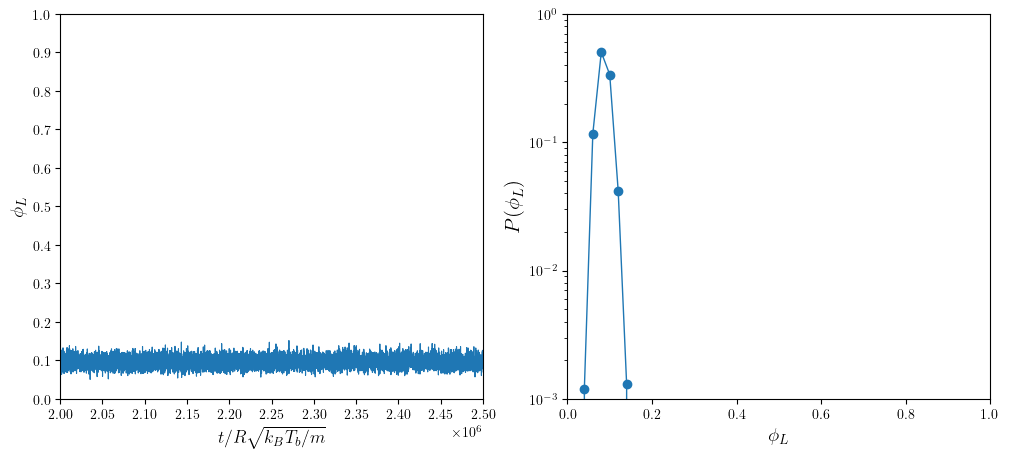

In [72]:
# Last modified : 17.06.25
# ax1 : Plot the lane order parameter as a function of time
# ax2 : Plot the distribution of the order parameter

nr_list = [48]
tau_list = [5e-4, 1e-3, 2e-3, 5e-3]

# Params for time series
eq_steps = 1e7
Nevery = 1
dt = [5e-5] + [5e-4] * (len(nr_list) - 1)
dt = 5e-4

# Params for probability distribution
xmax = 1.0
nBins = 50
binW = (xmax - 0)/nBins

fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (12, 5))
plt.ticklabel_format(style = "sci", axis = 'x', scilimits = (0,0))

for i in range(len(nr_list)):
    fpath = os.path.join(dirpath, "Pe90", "Data{nr}".format(nr = nr_list[i]), "laneOrder.dat")
    [[step, order], _] = readData(fpath, 1)

    # ax1 : time series
    time = [(j-eq_steps)*dt for j in step[0::Nevery]]
    order = order[0::Nevery]
    ax1.plot(time, order, "-", lw = 0.8, label = r"${tau}$".format(tau = tau_list[i]))

    [[step, order], _] = readData(fpath, 1)

    print(len(step), max(step))
    # ax2 : distribution of phi
    phi = np.linspace(0, xmax, nBins + 1)
    Bins = np.zeros(nBins + 1)

    for val in order:
        id = m.floor(val/binW)
        Bins[id] += int(1)

    totalCount = sum(Bins)
    
    for j in range(len(Bins)):
        Bins[j] /= totalCount

    ax2.semilogy(phi, Bins, "o-", lw = 1, label = r"${tau}$".format(tau = int(tau_list[i])))

    # ax1.set_title(r"$F_d^* = 90, ~\tau_{in}^* = {tau}$".format(tau=tau_list[i]), fontsize = 14, loc = "left")
    # ax2.set_title(r"$F_d^* = 90, ~\tau_{in}^* = {tau}$".format(tau=tau_list[i]), fontsize = 14, loc = "left")

# ax1.axhline(y = 1.0, xmin = 0, xmax = 1, linestyle = "--", color = "k", lw = 0.8)
ax1.set(xlim = (2.0e6, 2.5e6), ylim = (0, 1))
ax1.set_xlabel(r"$t/R\sqrt{k_BT_b/m}$", fontsize = 13)
ax1.set_ylabel(r"$\phi_L$", fontsize = 14)
ax1.set_xticks(np.arange(2.0e6, 2.55e6, 0.5e5))
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax2.set_xlabel(r"$\phi_L$", fontsize = 14)
ax2.set_ylabel(r"$P(\phi_L)$", fontsize = 15)
ax2.set(xlim = (0, xmax), ylim = (1e-3, 1))

# fig.savefig(os.path.join(figpath, "nr38_gamma1e3_laneOrderDist.png"), dpi = 500, bbox_inches = "tight")

In [ ]:
# Plot potential energy and laneOrder parameter of the system as a function of time

nr_list = [26, 27]
D = ["5e-4", "5e-3"]
month = ["May2025", "Apr2025", "May2025", "Apr2025"]

eq_steps = 1e7
dt = 5e-4
Nevery = 50

fig3, ax3 = plt.subplots(2, 1, figsize = (6, 6))

fpath = os.path.join("//media/ashwin/One Touch/ashwin_md/lane", month[0], "lmp", "Data{nr}".format(nr = nr_list[0]), "thermo.dat")
[[step, pe], _] = readData(fpath, 1)
time = [(i-eq_steps)*dt for i in step]
ax3[0].plot(time[0::Nevery], pe[0::Nevery], "-", lw = 0.5, label = D[0])

fpath = os.path.join("//media/ashwin/One Touch/ashwin_md/lane", month[0], "lmp", "Data{nr}".format(nr = nr_list[1]), "thermo.dat")
[[step, T, pe, ke, te], _] = readData(fpath, 1)
time = [(i-eq_steps)*dt for i in step]
ax3[0].plot(time[0::Nevery], pe[0::Nevery], "-", lw = 0.5, label = D[1])

for i in range(len(nr_list)):
    fpath = os.path.join("//media/ashwin/One Touch/ashwin_md/lane", month[0], "lmp", "Data{nr}".format(nr = nr_list[i]), "laneOrder.dat")
    [[time, order], _] = readData(fpath, 1)
    
    ax3[1].plot(time[0::Nevery], order[0::Nevery], "-", lw = 0.5, label = D[i])

ax3[0].set(xlim = (-5e4, max(time)))
ax3[0].set_ylim(bottom = 0)
ax3[1].set(xlim = (-5e4, max(time)), ylim = (0, 1.1))

ax3[0].set_ylabel(r"$U \sigma/k_BT$", fontsize = 11)
ax3[1].set_ylabel(r"$\phi_L$", fontsize = 11)

for i in ax3:
    i.set_xlabel(r"$t/\sigma\sqrt{k_BT/m}$", fontsize = 10)
    i.set_xticks(np.arange(0, 5.5e6, 0.5e6))
    i.legend(title = r"D$^*$")

ax3[0].set_title(r"$F_d^* = 90$", fontsize = 12, loc = "left")
plt.tight_layout()
# fig3.savefig(os.path.join(figpath, "order1.png"), dpi = 500, bbox_inches = "tight")

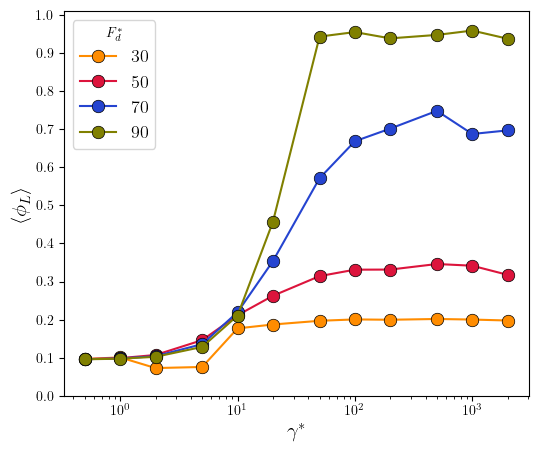

In [3]:
# Plot time-averaged lane order parameter vs F_d* and gamma*

fs = "full"
ms = 9
mew = 0.5

Fd_list = [30, 50, 70, 90]

fig6, ax6 = plt.subplots(figsize = (6, 5))

for i in range(len(Fd_list)):

    fpath = os.path.join(dirpath, "Pe{pe}".format(pe = Fd_list[i]), "avgOrder.dat")
    [data , _] = readData(fpath, 1)

    nr = data[0]
    gamma = data[1]
    order = data[4]

    ax6.semilogx(gamma, order, "-o", color = colors[i], mec = "k", ms = ms, mew = mew, fillstyle = "full", 
                    label = r"${pe}$".format(pe = Fd_list[i]))

ax6.set(ylim = (0, 1.01))
ax6.set_yticks(np.arange(0, 1.1, 0.1))
ax6.set_xlabel(r"$\gamma^*$", fontsize = 15)
ax6.set_ylabel(r"$\langle\phi_L\rangle$", fontsize = 15)
ax6.legend(title = r"$F_d^*$", fontsize = 13, loc = "upper left")

# fig6.savefig(os.path.join(figpath, "Phi_gamma_all.png"), dpi = 500, bbox_inches = "tight")

10000 0.0961931118 0.00018405281633253402

n_blk =  [2, 4, 5, 8, 10, 16, 20, 25, 40, 50, 80, 100, 125, 200, 250, 400, 500, 625, 1000, 1250, 2000, 2500, 5000] 
tau_blk =  [5000, 2500, 2000, 1250, 1000, 625, 500, 400, 250, 200, 125, 100, 80, 50, 40, 25, 20, 16, 10, 8, 5, 4, 2]

SEM = 0.006851959749671275 0.009666031102844506


Text(0, 0.5, '$\\sigma^2 (\\langle\\phi\\rangle_{blk})$')

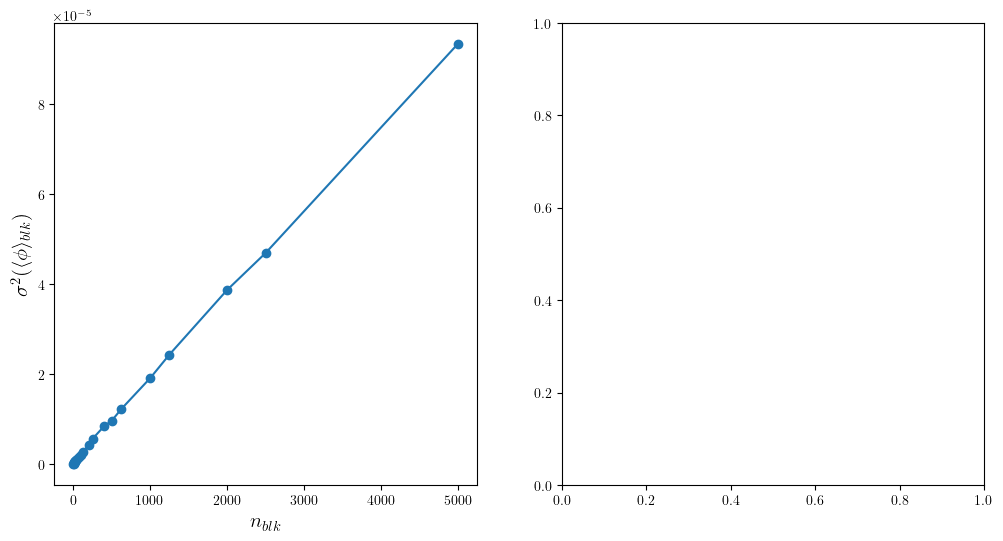

In [73]:
# Compute Standard Error of Mean (SEM) for a data set

fpath = os.path.join(dirpath, "Pe90", "Data48", "laneOrder.dat")
[[step ,order], _] = readData(fpath, 1)
order = order[1:]

tau_run = len(order)
run_avg = sum(order)/tau_run
sample_var = sum([(i - run_avg)**2 for i in order])
sample_var /= (tau_run - 1)

print(tau_run, run_avg, sample_var)

n_blk = []
tau_blk = []

for i in range(2, 5001, 1):
    if(tau_run%i == 0):
        n_blk.append(i)
        tau_blk.append(int(tau_run/i))

tau_blk_inv = [(1/i) for i in tau_blk]
        
print("\nn_blk = ", n_blk, "\ntau_blk = ", tau_blk)

blk_var = []
s = []
for i in range(len(n_blk)):
    blk_avg = np.zeros(n_blk[i])

    for blk in range(n_blk[i]):
        data = order[int(blk*tau_blk[i]):int((blk+1)*tau_blk[i])]
        blk_avg[blk] = sum(data)/len(data)

    total = 0
    for blk in range(n_blk[i]):
        total += (blk_avg[blk] - run_avg)**2

    blk_var.append(total/(n_blk[i]-1))
    s.append(blk_var[i]*tau_blk[i]/sample_var)
    
pos = len(blk_var)-1
print("\nSEM =", m.sqrt(blk_var[pos-1]), m.sqrt(blk_var[pos]))

fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (12, 6)) 
ax1.plot(n_blk, blk_var, "o-")
ax1.set_xlabel(r"$n_{blk}$", fontsize = 15)
ax1.set_ylabel(r"$\sigma^2 (\langle\phi\rangle_{blk})$", fontsize = 15)
# ax1.set_ylim(top = 0.001)

# ax2.plot(tau_blk, s, "o-")
# ax2.set_xlabel(r"$\tau_{blk}$", fontsize = 15)
# ax2.set_ylabel(r"$s(\tau_{blk})$", fontsize = 15)

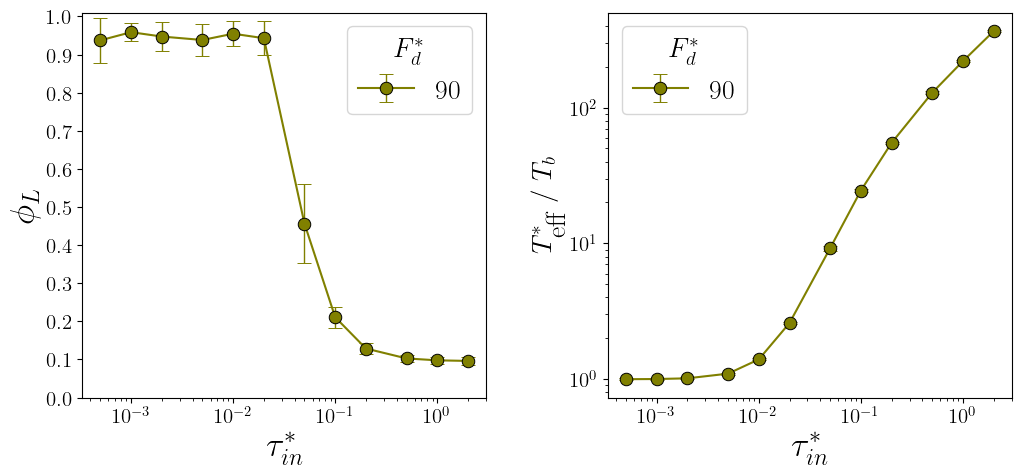

In [103]:
# Plot time-averaged lane order parameter and effective temp. with max and min bounds
# Last modified : 29.06.25

fs = "full"
ms = 9
mew = 0.7

fpath = os.path.join(dirpath, "Pe90", "avgOrder.dat")
[data, _] = readData(fpath, 1)

nr = data[0]
tau = data[1]
max_val = data[2]
min_val = data[3]
avg = data[4]
sem = data[5]

yerr = [[], []]
for i in range(len(nr)):
    yerr[0].append(abs(min_val[i] - avg[i]))
    yerr[1].append(abs(max_val[i] - avg[i]))

fig7, ax7 = plt.subplots(1, 2, figsize = (12, 5))
ax7[0].errorbar(tau, avg, yerr = sem, xerr = None, fmt = "-o", ecolor = colors[3], elinewidth = 1, capsize = 5,
             color = colors[3], ms = ms, mec = "k", mew = mew, fillstyle = fs, label = r"$90$")

ax7[0].set_xscale('log')

fpath = os.path.join(dirpath, "Pe90", "avgTemp.dat")
[[nr, tau, avg, sem], _] = readData(fpath, 1)

ax7[1].errorbar(tau, avg, yerr = sem, xerr = None, fmt = "-o", ecolor = colors[3], elinewidth = 1, capsize = 5,
             color = colors[3], ms = ms, mec = "k", mew = mew, fillstyle = fs, label = r"$90$")

ax7[1].set_xscale('log')
ax7[1].set_yscale('log')

ax7[0].set(ylim = (0, 1.01))
ax7[0].set_yticks(np.arange(0, 1.1, 0.1))
ax7[0].set_xlabel(r"$\tau_{in}^*$", fontsize = 25)
ax7[0].set_ylabel(r"$\phi_L$", fontsize = 25)
ax7[0].tick_params(axis='both', which='major', labelsize = 15)
leg = ax7[0].legend(title = r"$F_d^*$", fontsize = 20)
leg.get_title().set_fontsize("20")

ax7[1].set_xlabel(r"$\tau_{in}^*$", fontsize = 25)
ax7[1].set_ylabel(r"$T_{\textrm{eff}}^*~/~T_b$", fontsize = 20)
ax7[1].tick_params(axis='both', which='major', labelsize = 15)
leg = ax7[1].legend(title = r"$F_d^*$", fontsize = 20)
leg.get_title().set_fontsize("20")

plt.subplots_adjust(wspace = 0.3)

# fig7.savefig(os.path.join(figpath, "Phi_gamma_Fd90_bounds_SEM.png"), dpi = 500, bbox_inches = "tight")

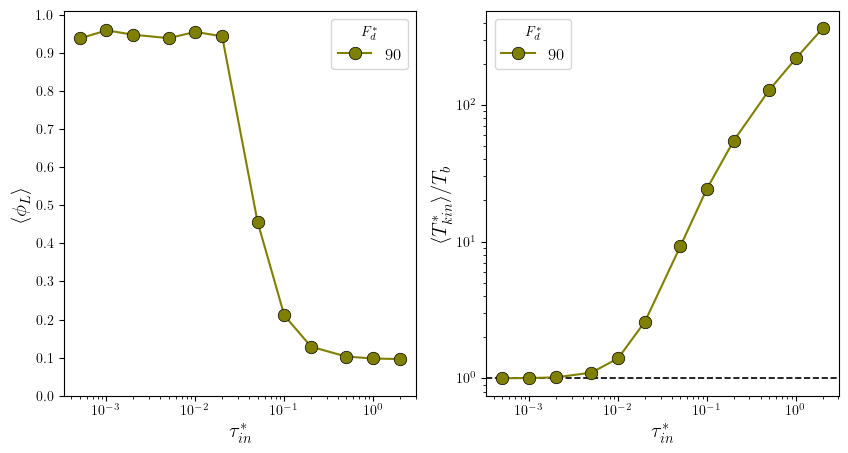

In [11]:
# Plot time-averaged lane order parameter and average temperature for varying tau_in*
# Last modified : 01.07.25

fs = "full"
ms = 9
mew = 0.5

Fd_list = [90]

fig7, ax7 = plt.subplots(1, 2, figsize = (10, 5))

ax7[1].axhline(y = 1.0, xmin = 0, xmax = 1, linestyle = "--", color = "k", lw = 1.2)
for i in range(len(Fd_list)):

    fpath = os.path.join(dirpath, "Pe{pe}".format(pe = Fd_list[i]), "avgThermo.dat")
    [[nr, tau, order, T], _] = readData(fpath, 1)

    ax7[0].semilogx(tau, order, "-o", color = colors[3], mec = "k", ms = ms, mew = mew, fillstyle = "full", 
                    label = r"${pe}$".format(pe = Fd_list[i]))
    ax7[1].loglog(tau, T, "-o", color = colors[3], mec = "k", ms = ms, mew = mew, fillstyle = "full",
                 label = r"${pe}$".format(pe = Fd_list[i]))

ax7[0].set(ylim = (0, 1.01))
ax7[0].set_yticks(np.arange(0, 1.1, 0.1))
ax7[0].set_xlabel(r"$\tau_{in}^*$", fontsize = 15)
ax7[0].set_ylabel(r"$\langle\phi_L\rangle$", fontsize = 15)
ax7[0].legend(title = r"$F_d^*$", fontsize = 12, loc = "upper right")
# ax7[].set_title(r"$F_d^* = 90$", fontsize = 12, loc = "left")

ax7[1].set_xlabel(r"$\tau_{in}^*$", fontsize = 15)
ax7[1].set_ylabel(r"$\langle T_{kin}^*\rangle/ T_b$", fontsize = 15)
ax7[1].legend(title = r"$F_d^*$", fontsize = 12, loc = "upper left")

# fig7.text(0.06, 0.85, r"$(a)$", fontsize = 15)
# fig7.text(0.5, 0.85, r"$(b)$", fontsize = 15)

# fig7.savefig(os.path.join(figpath, "Phi_temp_tau_Fd90.png"), dpi = 500, bbox_inches = "tight")